In [6]:
# Import required modules
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt


# Explore the data
team_flights = pd.read_csv('./data/team_flights.csv')
fuel_prices = pd.read_csv('./data/fuel_prices_2101.csv',
                         index_col='date')

print(team_flights.shape)
print(fuel_prices.shape)

print(team_flights.head())
print(fuel_prices.head())


# Some basic data cleaning and pre-processing
team_flights['departure_datetime'] = pd.to_datetime(team_flights['departure_datetime'])
team_flights['landing_datetime']   = pd.to_datetime(team_flights['landing_datetime'])

fuel_prices.index = pd.DatetimeIndex(fuel_prices.index).to_period('D')

(1145, 4)
(365, 1)
         team_name   departure_datetime     landing_datetime  \
0  Agile Antelopes  2102-04-06 21:37:00  2102-04-07 00:35:57   
1  Agile Antelopes  2102-04-10 23:57:00  2102-04-11 01:35:40   
2  Agile Antelopes  2102-04-14 00:29:00  2102-04-14 05:02:55   
3  Agile Antelopes  2102-04-21 03:31:00  2102-04-21 05:23:09   
4  Agile Antelopes  2102-04-24 22:23:00  2102-04-25 00:25:50   

   travel_distance_miles  
0            1491.250000  
1             822.222222  
2            2282.638889  
3             934.583333  
4            1023.611111  
            price
date             
2101-01-01   0.97
2101-01-02   0.87
2101-01-03   0.87
2101-01-04   0.97
2101-01-05   1.10


1) Maximum number of jets needed: a time-series graph that shows how many teams will be “in flight” throughout season


<bound method NDFrame.head of 0      2102-04-06 21:37:00
1      2102-04-10 23:57:00
2      2102-04-14 00:29:00
3      2102-04-21 03:31:00
4      2102-04-24 22:23:00
               ...        
1140   2102-09-05 03:14:19
1141   2102-09-08 04:26:26
1142   2102-09-18 23:00:50
1143   2102-09-23 05:40:32
1144   2102-09-26 00:17:24
Length: 2290, dtype: datetime64[ns]>


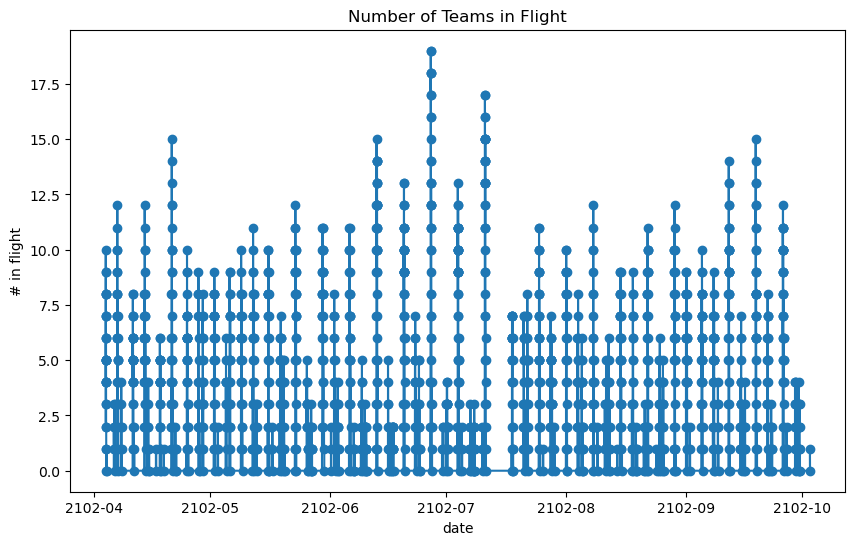

In [9]:
# first the minimum time between two unique flight event times in the season
all_datetimes = pd.concat([team_flights["departure_datetime"], team_flights["landing_datetime"]])
print(all_datetimes.head)
# sorting
all_datetimes_sorted = sorted(list(set(all_datetimes)))
# to DF
in_flight_df = pd.DataFrame({"date":sorted(all_datetimes_sorted), "in_flight":0})
# iterate through each known flight, and increment corresponding rows of in_flight_df
for index, flight in team_flights.iterrows():
    in_flight_df.loc[(in_flight_df['date']>=flight['departure_datetime']) &
                     (in_flight_df['date']<flight['landing_datetime']),'in_flight'] += 1

# Plot 
fig, ax = plt.subplots(figsize=(10, 6)) #optional size parameter
ax.step(in_flight_df['date'], in_flight_df['in_flight'], where='post') # optional
ax.scatter(in_flight_df['date'], in_flight_df['in_flight'])
ax.set_xlabel('date') # optional
ax.set_ylabel('# in flight') # optional
ax.set_title('Number of Teams in Flight') # optional
plt.show()

2) Jet fuel prices for next year:  using last year's jet fuel prices to project, apply these projections to every flight taken by every team to determine the overall fuel spend for next year

In [20]:
# fit seasonal ARIMA
model = SARIMAX(fuel_prices, 
                order = (1,1,1), # for linnear growth term 
                seasonal_order=(1,0,0,7)
                )
model_fitted = model.fit()

# forcast for upcoming year
forecast = model_fitted.get_forecast(steps = 365)

# to DF
fuel_prices_forecast = pd.DataFrame(data = {
    "date": forecast.summary_frame().index.to_timestamp(),
    "price":forecast.predicted_mean.values
})
print(fuel_prices_forecast)

# extract the date portion from the adjusted departure datetime
team_flights["departure_date"] = team_flights["departure_datetime"].dt.date

# join fuel_prices DataFrame based on the date
fuel_prices_forecast["date"] = fuel_prices_forecast["date"].dt.date
fuel_prices_forecast.set_index("date", inplace = True)
merged_df = team_flights.join(fuel_prices_forecast, on = "departure_date", how = "left")

print(merged_df.head())

# calculate the fuel cost for flights
merged_df["fuel_cost_total"] = merged_df["price"]*merged_df["travel_distance_miles"]

total_fuel_spend_projected = merged_df["fuel_cost_total"].sum()
print(total_fuel_spend_projected)


          date     price
0   2102-01-01  1.227121
1   2102-01-02  1.237165
2   2102-01-03  1.336954
3   2102-01-04  1.466678
4   2102-01-05  1.516572
..         ...       ...
360 2102-12-27  1.789139
361 2102-12-28  1.833916
362 2102-12-29  1.789139
363 2102-12-30  1.672719
364 2102-12-31  1.580587

[365 rows x 2 columns]
         team_name  departure_datetime    landing_datetime  \
0  Agile Antelopes 2102-04-06 21:37:00 2102-04-07 00:35:57   
1  Agile Antelopes 2102-04-10 23:57:00 2102-04-11 01:35:40   
2  Agile Antelopes 2102-04-14 00:29:00 2102-04-14 05:02:55   
3  Agile Antelopes 2102-04-21 03:31:00 2102-04-21 05:23:09   
4  Agile Antelopes 2102-04-24 22:23:00 2102-04-25 00:25:50   

   travel_distance_miles departure_date     price  
0            1491.250000     2102-04-06  1.600753  
1             822.222222     2102-04-10  1.335903  
2            2282.638889     2102-04-14  1.558699  
3             934.583333     2102-04-21  1.565168  
4            1023.611111     2102-04-24  1.